In [2]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

plt.style.use('../Analysis/sty.mplstyle')

# Carbon Form Factor

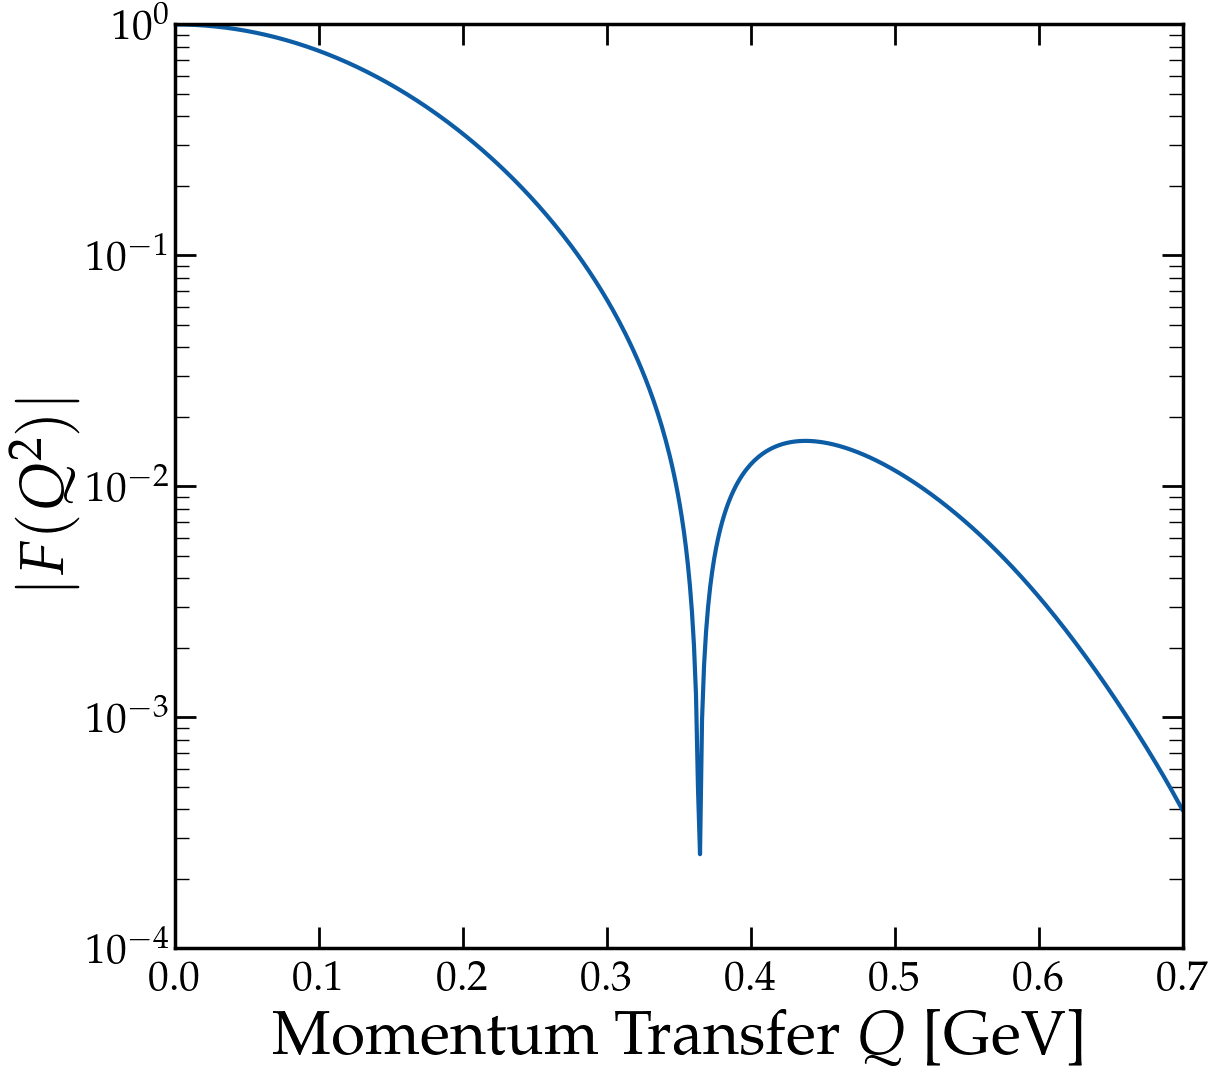

In [3]:
R_FBSE = 8/0.1973 # GeV^{-1}
a_FBSE = np.array([0.15721e-1, 0.38732e-1, 0.36808e-1, 0.14671e-1, -0.43277e-2,
                   -0.97752e-2, -0.68908e-2, -0.27631e-2, -0.63568e-3, 0.71809e-4,
                   0.18441e-3, 0.75066e-4, 0.51069e-4, 0.14308e-4, 0.23170e-5,
                   0.68465e-6], dtype=np.float64)

norm_FBSE = 0
for i in range(len(a_FBSE)):
    n = i + 1
    norm_FBSE -=  a_FBSE[i]*(-1)**n/n**2

def FBSE_FF(Q2):
    Q = np.sqrt(Q2)
    aux = np.ones_like(Q2)
    cond = Q!=0
    s = np.zeros_like(Q[cond])
    for i in range(len(a_FBSE)):
        n = i + 1
        s += ( a_FBSE[i]*(-1)**n/(Q[cond]*R_FBSE + n*np.pi) )*( np.sin(Q[cond]*R_FBSE)/(Q[cond]*R_FBSE - n*np.pi) )
    s = s*np.pi**2/(Q[cond]*R_FBSE)
    aux[cond] = s/norm_FBSE
    return aux

def Squared_FBSE_FF(Q2):
    return FBSE_FF(Q2)**2

def u1_Carbon(Q2):
    main, _ = quad(Squared_FBSE_FF, Q2, np.infty, limit=1000)
    return main

u1_Carbon = np.vectorize(u1_Carbon)

q2_Alt = np.loadtxt('../csv/InterpolationList/Argon/40Ar_InterpolationList3pF_Altmannshofer.txt', delimiter=',', usecols=0)
u1_Carbon_valores = u1_Carbon(q2_Alt)    

Qvalores = np.linspace(0, 0.7, 500)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Qvalores, np.abs(FBSE_FF(Qvalores**2)))
ax.set_ylim([1e-4, 1])
ax.set_yscale('log')
ax.set_xlim([0, Qvalores.max()])
ax.set_ylabel(r'$|F(Q^2)|$')
ax.set_xlabel(r'Momentum Transfer $Q$ [GeV]')

#ax.plot(q2_Alt, u1_Carbon_valores)
#ax.set_yscale('log')
#ax.set_xlim([0, 2.6])
#ax.set_ylabel(r'$u_1(Q^2)$ [GeV$^2$]')
#ax.set_xlabel(r'$Q^2$ [GeV$^2$]')

# Writing to CSV
with open("../csv/InterpolationList/Carbon/InterpolationList_Carbon_FourierBesel.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1_Carbon_valores):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

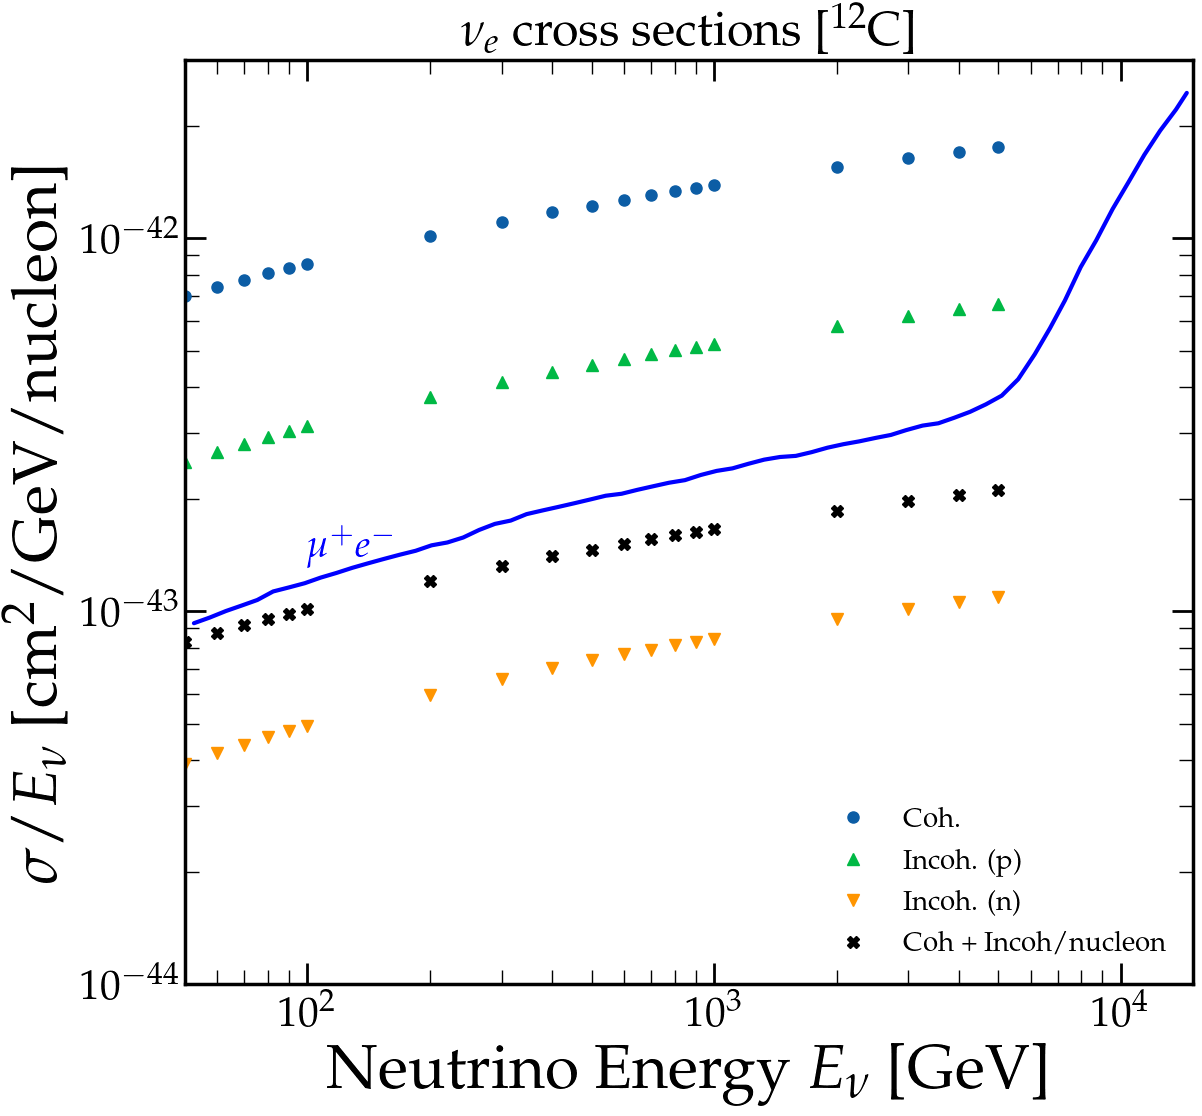

In [4]:
xvalues = np.loadtxt('Digitized_MuC_xsecs_nue.txt', usecols=0)
yvalues = np.loadtxt('Digitized_MuC_xsecs_nue.txt', usecols=1)

Enu_Cpp = np.loadtxt('ve_to_vmu_mu+_e-.txt', usecols=0) # GeV
Coherent_Cpp = 1e-39*np.loadtxt('ve_to_vmu_mu+_e-.txt', usecols=1) # cm^2
Protons_Cpp = 6e-39*np.loadtxt('ve_to_vmu_mu+_e-.txt', usecols=2) # cm^2
Neutrons_Cpp = 6e-39*np.loadtxt('ve_to_vmu_mu+_e-.txt', usecols=3) # cm^2
Xsec_tot = Coherent_Cpp + Protons_Cpp + Neutrons_Cpp

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(xvalues, yvalues, color='blue')
ax.plot(Enu_Cpp, Coherent_Cpp/Enu_Cpp, marker='o', ls='', markersize=8, label='Coh.')
ax.plot(Enu_Cpp, Protons_Cpp/Enu_Cpp, marker='^', ls='', markersize=8, label='Incoh. (p)')
ax.plot(Enu_Cpp, Neutrons_Cpp/Enu_Cpp, marker='v', ls='', markersize=8, label='Incoh. (n)')
ax.plot(Enu_Cpp, Xsec_tot/Enu_Cpp/12, marker='X', color='k', ls='', markersize=8, label='Coh + Incoh/nucleon')

ax.legend(loc='lower right', fontsize=20)


ax.set_ylim([1e-44, 3e-42])
ax.set_xlim([50, 1.5e4])
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title(r'$\nu_e$ cross sections [$^{12}$C]')
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
ax.set_ylabel(r'$\sigma/E_\nu$ [cm$^2$/GeV/nucleon]')
ax.text(1e2, 1.4e-43, r'$\mu^{+} e^{-}$', color='blue')

plt.savefig('FigPrueba.png', bbox_inches='tight', transparent=False)